(200, 200)


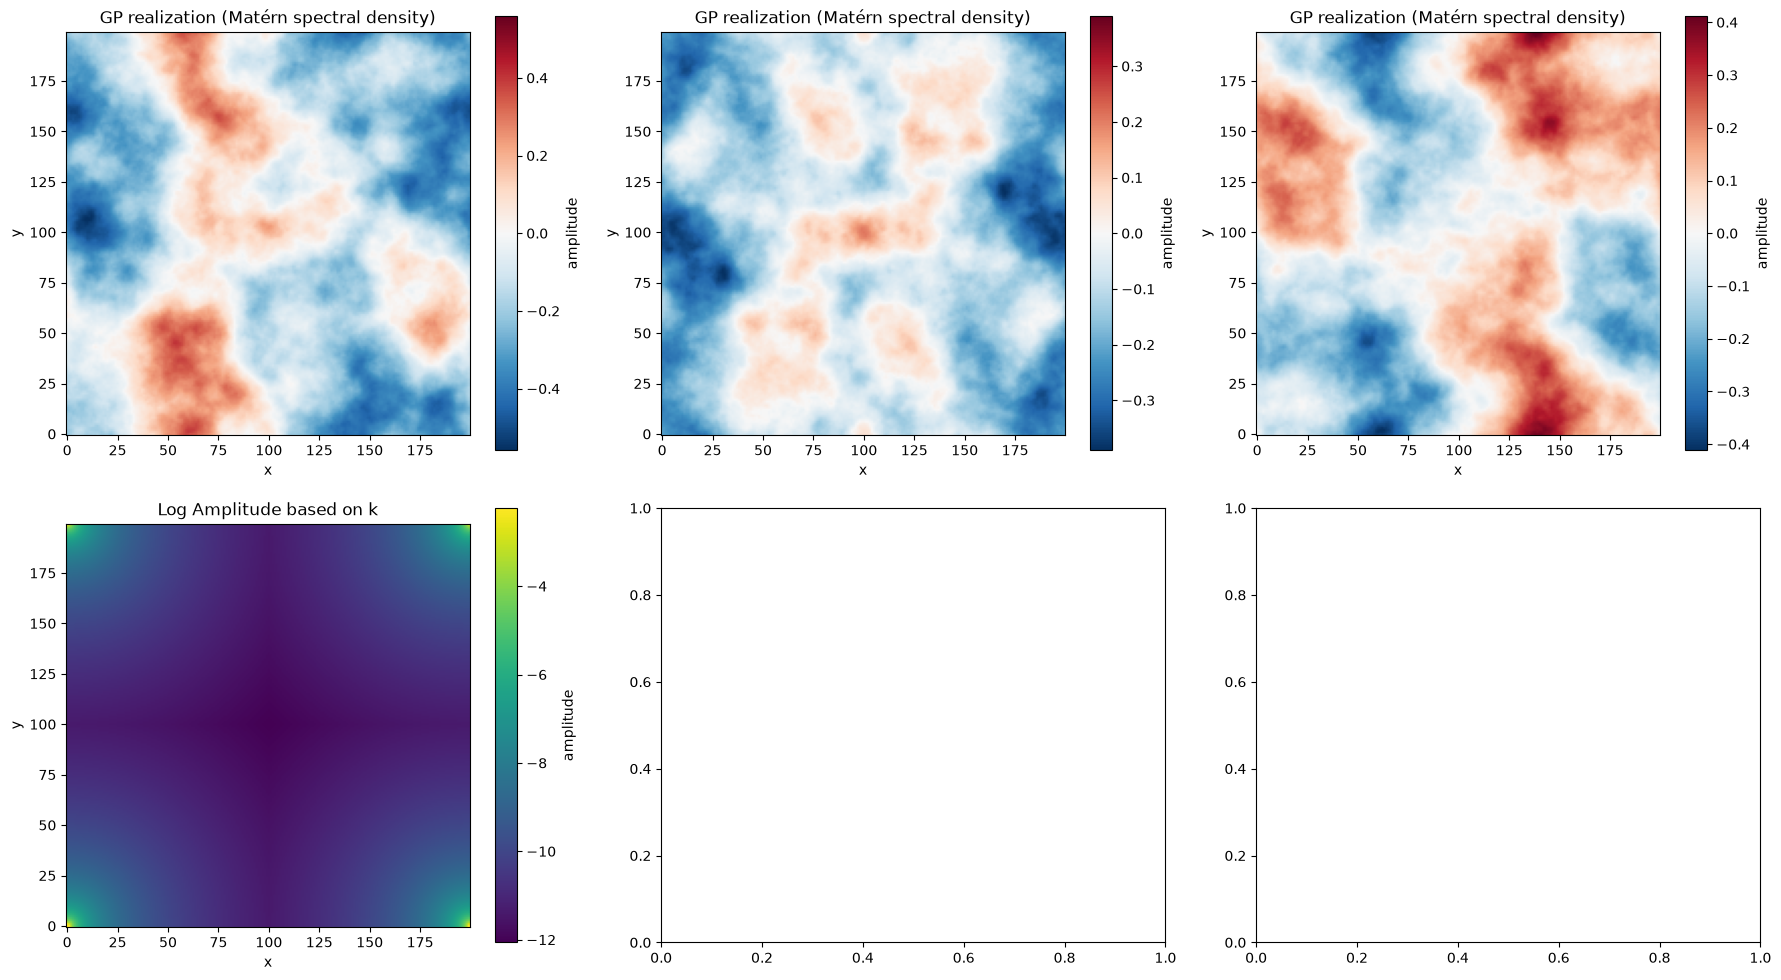

In [17]:
import jax
import jax.numpy as jnp
import jax.scipy as jsp
import jax.random as jr

import matplotlib.pyplot as plt

def fft_gp(logk, logp, xi, *, pad):
    kvec = jnp.meshgrid(*tuple(jnp.fft.fftfreq(n)*max(xi.shape) for n in xi.shape), indexing='ij')
    k = jnp.linalg.norm(jnp.stack(kvec), axis=0)
    amplitude = jnp.exp(0.5 * jnp.interp(k, jnp.exp(logk), logp))
    density = jnp.fft.fftn(amplitude * xi)
    realdensity = density.real
    imagdensity = density.imag
    density = (density.real - density.imag)
    return amplitude, density[tuple(slice(pad, n-pad) for n in xi.shape)], density.shape, realdensity[tuple(slice(pad, n-pad) for n in xi.shape)], imagdensity[tuple(slice(pad, n-pad) for n in xi.shape)]

def matern_spectral_density(omega, variance=1.0, scale=1, jitter=1e-6):
    result = variance * scale * 12 * jnp.sqrt(3)/((3 + (scale*omega)**2)**2)
    return jnp.where(omega > 0, result, result * (1.0 + jitter))


logk = jnp.linspace(0, 5, 1000)
logp = jnp.log(matern_spectral_density(2*jnp.pi*jnp.exp(logk)))



fig, axes = plt.subplots(2, 3, figsize=(18, 10))
rng = jr.PRNGKey(6)
rng, k1, k2 = jr.split(rng, 3)
xi = jr.normal(k1, (200, 200))


k_amplitude, gp_data, shape, gp_real, gp_imag = fft_gp(logk, logp, xi, pad = 0)
print(shape)

im = axes[0, 0].imshow(
    gp_data, cmap='RdBu_r', origin='lower',
    vmin=-jnp.abs(gp_data).max(), vmax=jnp.abs(gp_data).max()
)
fig.colorbar(im, ax=axes[0, 0], label='amplitude')
axes[0, 0].set_title('GP realization (Matérn spectral density)')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('y')

im = axes[0, 1].imshow(
    gp_real, cmap='RdBu_r', origin='lower',
    vmin=-jnp.abs(gp_real).max(), vmax=jnp.abs(gp_real).max()
)
fig.colorbar(im, ax=axes[0, 1], label='amplitude')
axes[0, 1].set_title('GP realization (Matérn spectral density)')
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('y')

im = axes[0, 2].imshow(
    gp_imag, cmap='RdBu_r', origin='lower',
    vmin=-jnp.abs(gp_imag).max(), vmax=jnp.abs(gp_imag).max()
)
fig.colorbar(im, ax=axes[0, 2], label='amplitude')
axes[0, 2].set_title('GP realization (Matérn spectral density)')
axes[0, 2].set_xlabel('x')
axes[0, 2].set_ylabel('y')

im = axes[1, 0].imshow(
    jnp.log(k_amplitude), cmap='viridis', origin='lower',
)
fig.colorbar(im, ax=axes[1, 0], label='amplitude')
axes[1, 0].set_title('Log Amplitude based on k')
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('y')

plt.tight_layout()
plt.show()
